# Veri Analizi ve Görselleştirme: Teorik ve Pratik Derinlemesine İnceleme

Bu notebook, bir veri setinin (`social_media_vs_productivity.csv`) başından sonuna kadar nasıl inceleneceğini hem **kod (pratik)** hem de **teorik altyapı** sunarak detaylandırmaktadır. Amacımız, sadece metodları çağırmak değil, *"Bu metodu neden çağırıyoruz?"* ve *"Bu grafik ne anlama geliyor?"* sorularına profesyonel yanıtlar vermektir.

## 1. Veri Yükleme ve Temel DataFrame Analiz Metotları (Data Exploration)

### Neden Keşifsel Veri Analizi (EDA) Yaparız?
EDA, verilerin yapısını anlamak, olası hataları (missing values, outliers) tespit etmek ve makine öğrenmesi modellerine vermeden önce veriyi uygun formata getirmek için yapılan ilk ve en kritik adımdır.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

df = pd.read_csv('social_media_vs_productivity.csv')
df

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,34,Female,Health,1.877297,Facebook,59,10.226358,3.348512,3.465815,8.0,5.480462,1.412655,9,False,False,4,5,21.776927,NaN
29996,39,Male,Health,4.437784,Instagram,46,4.692862,8.133213,6.659294,8.0,3.045393,0.148936,3,False,False,1,29,4.111370,6.155613
29997,42,Male,Education,17.724981,TikTok,64,10.915036,8.611005,8.658912,5.0,5.491520,1.224296,10,False,False,1,2,1.888315,6.285237
29998,20,Female,Education,3.796634,Instagram,56,6.937410,7.767076,6.895583,8.0,6.816069,0.234483,1,False,False,2,9,12.511871,7.854711


### A. `df.shape` (Veri Setinin Boyutsallığı)
**Teori:** Veri setinin satır (gözlem) ve sütun (özellik/feature) sayısını verir. Boyut satırı, modelin eğitimi için ne kadar örneğe sahip olduğumuzu; sütun sayısı ise "Boyut Laneti (Curse of Dimensionality)" riski taşıyıp taşımadığımızı gösterir. Çok fazla sütun (özellik) varsa, modeller gürültüyü öğrenebilir (overfitting).

In [3]:
print(f"Satır (Gözlem) Sayısı: {df.shape[0]}")
print(f"Sütun (Özellik) Sayısı: {df.shape[1]}")

Satır (Gözlem) Sayısı: 30000
Sütun (Özellik) Sayısı: 19


### B. `df.info()` ve `df.memory_usage()`
**Teori:** `info()`, sütunların veri tiplerini (int, float, object), boş olmayan (non-null) eleman sayısını ve RAM kullanımını gösterir.
- **Neden Önemli?** Makine öğrenmesi algoritmaları genellikle sadece sayısal (numeric) verilerle çalışır. Categorical (object) olarak görünen ama aslında sayısal mantıkta olan verileri tespit etmemizi sağlar. Bellek kullanımı, büyük verilerde (Big Data) veri tiplerini küçülterek (örn. float64 -> float32) optimizasyon yapmamıza olanak tanır.

In [4]:
df.info()
# Bellek kullanımını sütun bazında daha detaylı görmek için:
# df.memory_usage(deep=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work              

### C. `df.describe()` (Beş Sayı Özeti - Five-Number Summary)
**Teori:** Sayısal sütunların merkezi eğilim (Ortalama-Mean, Medyan-50%) ve dağılım (Standart Sapma-Std, Min, Max) metriklerini gösterir.
- **Standart Sapma (std):** Verilerin ortalamaya ne kadar yakın dağıldığını gösterir. Yüksek std, verilerin çok dağınık olduğu anlamına gelir.
- **Beş Sayı Özeti:** Min, 25% (Q1), 50% (Medyan-Q2), 75% (Q3), Max. IQR (Interquartile Range) = Q3 - Q1 formülü ile hesaplanır ve aykırı değerleri (outliers) bulmakta istatistiksel temel oluşturur. Eğer (Mean) ile (50%-Median) arasında ciddi bir fark varsa, veri normal dağılıma sahip değildir (çarpıktır).

In [5]:
df.describe()

,age,daily_social_media_time,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
count,30000.000000,27235.000000,30000.000000,30000.000000,28386.000000,27635.000000,28096.000000,27402.000000,27789.000000,30000.000000,30000.000000,30000.000000,30000.000000,27270.000000
mean,41.486867,3.113418,59.958767,6.990792,5.510488,4.951805,5.514059,6.500247,1.025568,4.992200,1.999300,15.557067,10.360655,4.964901
std,13.835221,2.074813,7.723772,1.997736,2.023470,1.883378,2.866344,1.464004,0.653355,3.173737,1.410047,9.252956,7.280415,2.121194
min,18.000000,0.000000,30.000000,0.000000,2.000252,0.296812,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.639566,55.000000,5.643771,3.757861,3.373284,3.000000,5.493536,0.528490,2.000000,1.000000,8.000000,4.541872,3.363580
50%,41.000000,3.025913,60.000000,6.990641,5.525005,4.951742,6.000000,6.498340,1.006159,5.000000,2.000000,16.000000,10.013677,4.951049
75%,53.000000,4.368917,65.000000,8.354725,7.265776,6.526342,8.000000,7.504143,1.477221,8.000000,3.000000,24.000000,15.300809,6.581323
max,65.000000,17.973256,90.000000,12.000000,8.999376,9.846258,10.000000,10.000000,3.000000,10.000000,10.000000,31.000000,40.964769,10.000000


### D. Diğer Önemli Keşif Metotları
- **`df.duplicated()`:** Veri setindeki birebir aynı olan tekrarlı satırları tespit eder. Tekrarlı veriler modelin aynı örneği birden fazla kez öğrenmesine (bias) yol açabilir.
- **`df.value_counts()`:** Kategorik sütunlarda her bir sınıfın (sınıf) ne kadar geçtiğini frekans oranlarıyla gösterir. Veri dengesizliği (class imbalance) tespitinin temel adımıdır.

In [6]:
print(f"Yinelenen (Duplicate) Satır Sayısı: {df.duplicated().sum()}\n")
print("Meslek Grupları Frekansı:\n", df['job_type'].value_counts())

Yinelenen (Duplicate) Satır Sayısı: 0

Meslek Grupları Frekansı:
 job_type
Education     5055
IT            5026
Finance       5017
Student       5012
Unemployed    4958
Health        4932
Name: count, dtype: int64


## 2. Veri Dağılımı ve Dengesizlik (Imbalance) Tespiti

### A. Çarpıklık (Skewness) ve Basıklık (Kurtosis)
- **Skewness (Çarpıklık):** Dağılımın asimetrisini ölçer. 
  - Skewness = 0 ise Tam Normal (Simetrik) dağılımdır.
  - Skewness > 0 ise Sağa Çarpık (Positive Skew). Kuyruk sağa uzanır, genelde Mean > Median'dır.
  - Skewness < 0 ise Sola Çarpık (Negative Skew). Kuyruk sola uzanır, genelde Mean < Median'dır.

![Skewness Types](https://upload.wikimedia.org/wikipedia/commons/f/f8/Negative_and_positive_skew_diagrams_%28English%29.svg)


- **Kurtosis (Basıklık):** Dağılımın kuyruklarının kalınlığını veya aşırı uç (outlier) değerlerin ne kadar yoğun olduğunu ölçer. Normal dağılımın basıklığı 3'tür.

  - **Mesokurtic:** Kurtosis ≈ 3. Normal dağılımı temsil eder.
  - **Leptokurtic:** Kurtosis > 3. Dağılım sivridir ve kuyruklar kalındır (aykırı değer olasılığı yüksek).
  - **Platykurtic:** Kurtosis < 3. Dağılım basıktır ve kuyruklar incedir.



**Neden Önemli?** Lineer regresyon, ANOVA gibi klasik istatistiksel modeller değişkenlerin normal dağıldığını varsayar. Yüksek çarpıklık varsa logaritmik veya karekök dönüşümleri uygulamak gerekir.

### B. Sınıf Dengesizliği (Class Imbalance)
- **Tanım:** Bir veri setindeki hedef sınıfların (label) örnek sayılarının birbirine yakın olmaması durumudur. Özellikle ikili sınıflandırma (binary classification) problemlerinde bir sınıfın (çoğunluk), diğer sınıfa (azınlık) göre çok daha fazla temsil edilmesiyle görülür.

- **Neden Önemli?**
  - **Model Yanlılığı (Bias):** Makine öğrenmesi modelleri genellikle toplam hata oranını minimize etmeye çalışır. Bu durumda model, azınlık sınıfını tamamen görmezden gelse bile yüksek doğruluk (accuracy) skoru elde edebilir.
  - **Accuracy Paradox:** Örneğin, verinin %99'u "Negatif" ise, model her şeye "Negatif" diyerek %99 başarı elde eder ancak asıl tespit edilmek istenen %1'lik "Pozitif" vakaları (hastalık, dolandırıcılık vb.) asla bulamaz.

- **Nasıl Tespit Edilir?**
  - Hedef değişkenin frekans dağılımına bakılarak (`value_counts()` veya `countplot`).

- **Baş Etme Yöntemleri:**
  - **Yeniden Örnekleme (Resampling):** Azınlık sınıfını artırma (Over-sampling / SMOTE) veya çoğunluk sınıfını azaltma (Under-sampling).
  - **Metrik Seçimi:** Accuracy yerine Precision, Recall, F1-Score ve ROC-AUC gibi metriklerin kullanılması.
  - **Algoritmik Yaklaşımlar:** Sınıf ağırlıklarını (class weights) dengeleyen modeller kullanmak.


In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
dist_df = pd.DataFrame({
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurtosis()
})
dist_df

,Skewness,Kurtosis
age,0.015305,-1.191197
daily_social_media_time,1.191641,5.205230
number_of_notifications,0.117736,0.040780
work_hours_per_day,-0.038162,-0.159041
perceived_productivity_score,-0.011157,-1.204322
actual_productivity_score,-0.006768,-1.036228
stress_level,0.000951,-1.218117
sleep_hours,0.003997,-0.325900
screen_time_before_sleep,0.304198,-0.433528
breaks_during_work,0.006698,-1.229997


### B. Majority (Çoğunluk) ve Minority (Azınlık) Sınıf Tespiti ve Etkileri

Classification (sınıflandırma) problemlerinde hedef değişken (target) kategorik olduğunda, bir sınıf örneğin veri setinin %95'ini (Majority), diğer sınıf ise %5'ini (Minority) oluşturabilir. 

**Nasıl Yorumlanır?**
Yukarıdaki `value_counts(normalize=True)` komutu ile bu dağılım oranını görebiliriz. Eğer %80-%20 veya daha keskin bir oran varsa model **"Dengesiz" (Imbalanced)** bir veriyle karşı karşıyadır.

**Etkisi:** Makine öğrenmesi modeli, kayıp fonksiyonunu minimize etmek için kolaya kaçıp her yeni gelen veriye her zaman %95'lik sınıf (Majority) etiketini atayabilir. Modelin doğruluk (% accuracy) skoru %95 çıkar ancak aslında model *hiçbir azınlık sınıfını (Minority) yakalayamamıştır* (Örn: Dolandırıcılık tespiti, hastalıklı hücre tespiti).

**Dengesizliği Önleme Yöntemleri (Neden Kullanılırlar?):**
1. **Undersampling (Alt Örnekleme):** Çoğunluk sınıfından rastgele örnekler silinerek sınıf sayıları eşitlenir. Hızlıdır ama değerli bilgi (verinin kendisi) kaybedilir.
2. **Oversampling (Aşırı Örnekleme):** Azınlık sınıfı kopyalanarak veya sentetik örneklerle sayıları artırılır. Overfitting (ezberleme) riski taşıyabilir.
3. **SMOTE (Synthetic Minority Over-sampling Technique):** Azınlık sınıfların k-Nearest Neighbors mantığı kullanılarak sentetik ve istatistiksel açıdan anlamlı kopyaları yaratılır. Dengesizliği çözmede en çok tercih edilen yöntemdir.
4. **Class Weights (Sınıf Ağırlıklandırma):** Algoritma seviyesinde çözümdür. Hedef sınıflara veri manipülasyonu yapmadan modelin öğrenme şamasında "Azınlık sınıfını hatalı tahmin edersen penalization (ceza) skorunu artır" diyerek denge sağlanır.

## 3. Görselleştirme Teorisi (Visualization Theory)

Veriyi anlamlı bir hikayeye dönüştürmek için grafikler kullanılır. Grafiğin parametreleri oynanarak farklı derinlikte bilgiler edilir. Seaborn ve Matplotlib temel görselleştirme kütüphaneleridir.

### A. Bar Chart (Sütun Grafiği)
**Neden Kullanılır?** Kategorik değişkenlerin frekanslarını (miktarlarını) veya kategoriler arasında nicel değerleri (ortalama vb.) karşılaştırmak için kullanılır.
**Avantajları:** İnsan gözü uzunlukları ve yükseklikleri karşılaştırmada çok iyidir, kategorik verilerin anlaşılmasında en efektif yöntemdir.

**Dezavantajları:** Sürekli (continuous) sayısal distribüsyonları göstermek için anlamsızdır.

**Görsel Parametreler ve Etkileri:**
- `hue`: Verilmiş bir ana kategoriye (örn. Meslek) **ikinci bir alt kırılım/boyut** ekler (örn. Cinsiyet). Bu parametre sayesinde iki değişkenin ana değişkene etkisini aynı karede görebilirsiniz.
- `palette`: Renk setidir. Görselliğin yanında zıt renkler (diverging) kullanarak farklı kategorilerin bilişsel algısını kolaylaştırır.

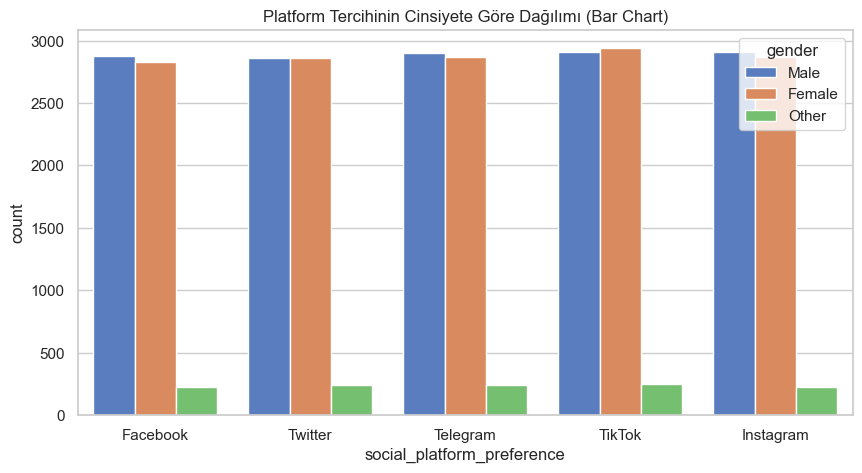

In [8]:
plt.figure(figsize=(10,5))
# hue parametresi kullanımı
sns.countplot(data=df, x='social_platform_preference', hue='gender', palette='muted')
plt.title('Platform Tercihinin Cinsiyete Göre Dağılımı (Bar Chart)')
plt.show()

### B. Histogram
**Neden Kullanılır?** Sürekli (nicel - numeric) bir değişkenin veri seti içerisinde nasıl bir dağılım izlediğini (çan eğrisi, sağa/sola çarpık, bimodal vs.) göstermek için kullanılır.

**Avantajları:** Tepe noktası (mod/yoğunluğun olduğu yer) neresi sorusunu doğrudan yanıtlar.

**Dezavantajları:** Yanlış `bins` (kanal/kutu sayısı) seçimi, verideki gerçek paterni gizleyebilir.

**Görsel Parametreler ve Etkileri:**
- `bins`: Sayısal aralığı kaç parçaya/kutuya böleceğini belirtir. `bins` çok küçükse (ör: 5), verideki ince dalgalanmalar kaybolur (underfitting). `bins` çok yüksekse (ör: 200), grafik aşırı gürültülü (spiky) görünür.
- `kde` (Kernel Density Estimation): Veri üzerine eğrisel, sürekli bir yoğunluk tahmini çizgisi çizer. Dağılımın temel formunu (tepesi, kuyruğu) kesikliklerden arındırılmış halde sunar.

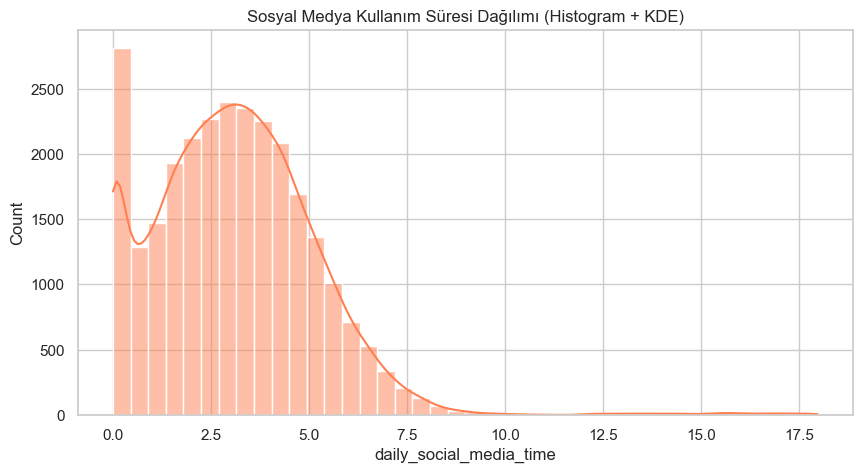

In [9]:
plt.figure(figsize=(10,5))
# bins sayısı 40 ve kde eğrisi aktif
sns.histplot(data=df, x='daily_social_media_time', bins=40, kde=True, color="coral")
plt.title('Sosyal Medya Kullanım Süresi Dağılımı (Histogram + KDE)')
plt.show()

### C. Box Plot (Kutu Grafiği)
**Neden Kullanılır?** İki veya çok gruplu sayısal bir verinin **medyan**, **çeyreklikler (Q1-Q3)** ve **aykırı değerlerini (outliers)** aynı anda göstermek için kullanılır. İstatistiksel bir özet görselidir.

**Avantajları:** Veri dağılımı yerine merkezi dağılımın genişliğine odaklanır (IQR alanı). Outlier (aykırı uç noktalar) tespitinde en iyi görseldir.

**Dezavantajları:** Gruplar çok büyük/kompleks veya bimodal (iki tepeli) dağılıma sahipse, KDE eğrisindeki gibi bu iç detayları gizler (Bunun yerine Violin Plot kullanılabilir).

**Teorik Arka Plan (IQR Yöntemi):**
Kutunun alt sınırı 25. yüzdelik (Q1), ortasındaki çizgi Medyan (Q2), üst sınırı 75. yüzdeliktir (Q3). 
IQR (Interquartile Range) = Q3 - Q1'dir. Bıyıkların ötesindeki (kutunun dışındaki noktalar) min/max sınırlar `Q1 - 1.5 * IQR` veya `Q3 + 1.5 * IQR` formülü ile saptanır. Bu sınırların dışındaki her şey "nokta" olarak çizilir (Aykırı Değer).


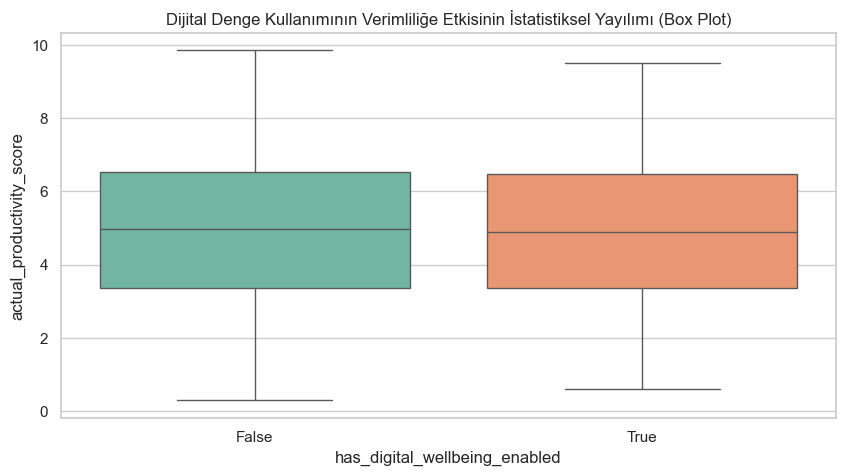

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='has_digital_wellbeing_enabled', y='actual_productivity_score', palette='Set2')
plt.title('Dijital Denge Kullanımının Verimliliğe Etkisinin İstatistiksel Yayılımı (Box Plot)')
plt.show()

### D. Scatter Plot (Serpilme Diyagramı)
**Neden Kullanılır?** İki **sayısal** değişken (örn. Süre ve Skor) arasındaki korelasyonu (ilişki yönünü ve şeklini) görmek için kullanılır.

**Avantajları:** Doğrusal, kümelenmiş veya eğrisel ilişkileri anında görselleştirir.

**Dezavantajları:** Veri sayısı on binler/yüz binler seviyesindeyse, noktalar üst üste binerek (Overplotting) okunamaz devasa bir mürekkep yumağına dönüşür.

**Görsel Parametreler ve Etkileri:**
- `alpha`: Noktaların saydamlığını belirtir (0.0 ile 1.0 arası). Örn `alpha=0.3` olursa, noktalar üst üste bindiği yerlerde daha koyu görünür; böylece "Overplotting (aşırı örtüşme)" sorununu kısmen çözer ve veri yoğunluğunun nerede biriktiğini (Density) algılamanızı sağlar.

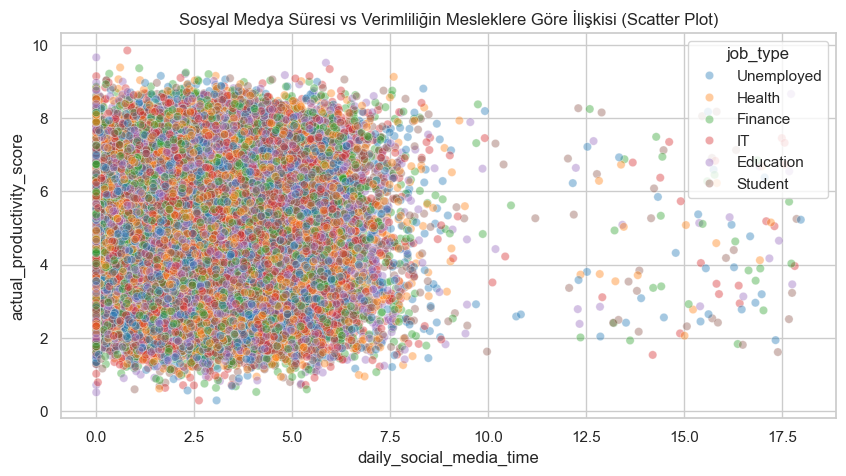

In [11]:
plt.figure(figsize=(10,5))
# Yoğunluğu (density) görebilmek için alpha düşürüldü
sns.scatterplot(data=df, x='daily_social_media_time', y='actual_productivity_score', hue='job_type', alpha=0.4, palette="tab10")
plt.title('Sosyal Medya Süresi vs Verimliliğin Mesleklere Göre İlişkisi (Scatter Plot)')
plt.show()

## 4. Gelişmiş Korelasyon Analizi (`df.corr()`)
**Teori:** Korelasyon matrisi hesaplanırken genellikle **Pearson Korelasyon Katsayısı** kullanılır (-1 ile 1 arası). Doğrusal ilişkiler arar (Lineer regresyonun temelidir).
- Eğer ilişkiler doğrusal değil (logaritmik vb.) ise **Spearman Rank Korelasyonu** (`df.corr(method='spearman')`) kullanılması teorik olarak daha doğru ve outliarlara karşı daha dirençlidir.

Isı haritaları (Heatmap), korelasyon matrisi çok büyük olduğunda gözün rakamları algılamaktaki zorluğunu renk yoğunluğu boyutuna aktararak (Red = Pozitif Yüksek ilişki, Blue = Negatif Yüksek ilişki) çözümler.

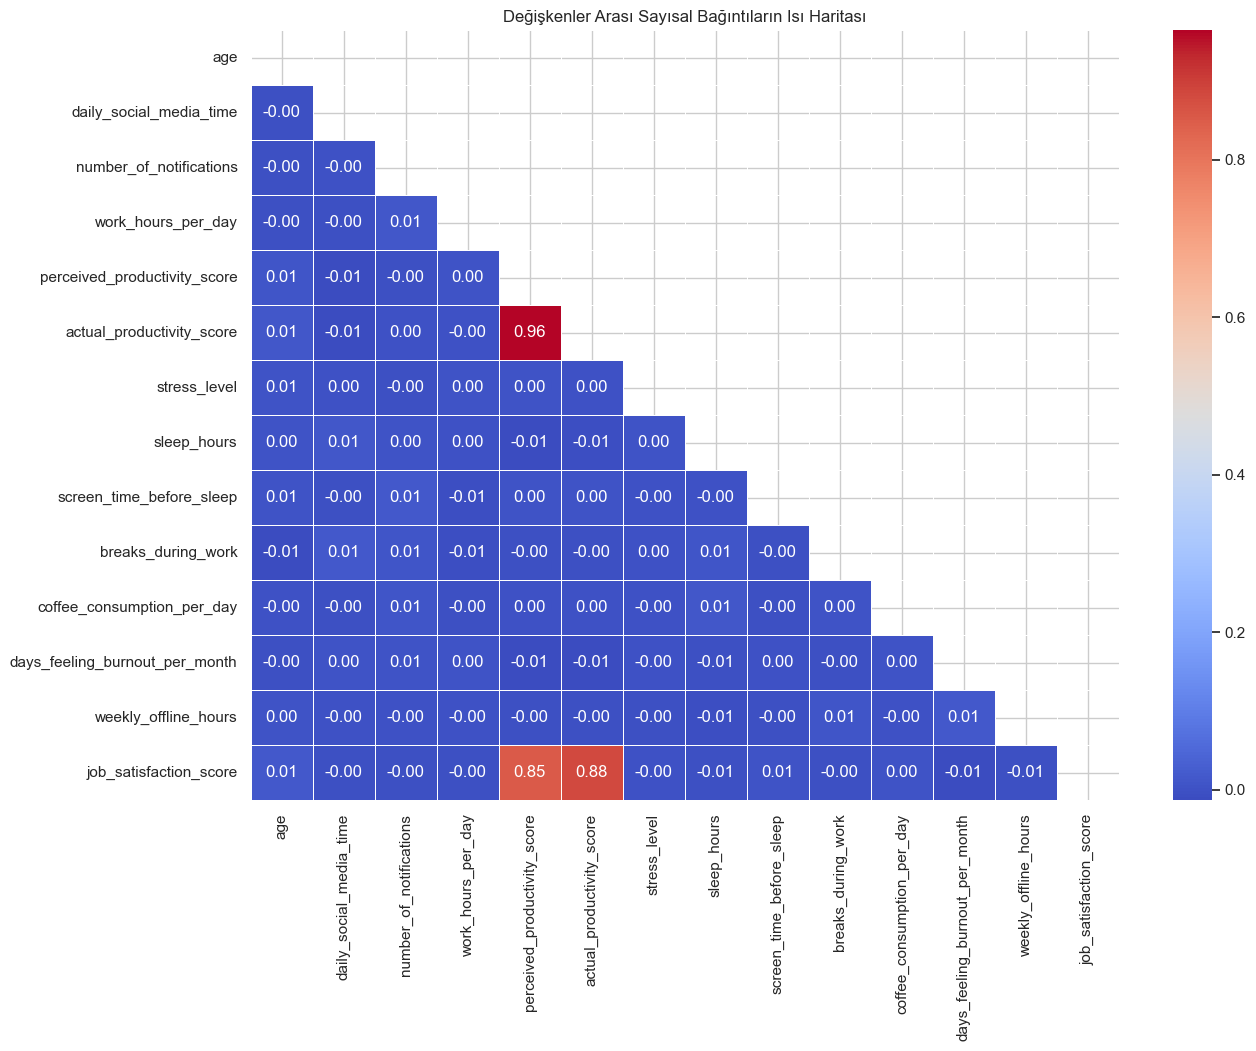

In [12]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14,10))
# fmt='.2f': virgülden sonraki sayı duyarlılığı (çok fazla parametre okunabilirliği engeller)
# cmap='coolwarm': Zıt renk spektrumu korelasyon yönünü hızla anlatır
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Değişkenler Arası Sayısal Bağıntıların Isı Haritası')
plt.show()

### Sonuç: Isı Haritasının Özeti
- Heatmap bize **"Hangi feature (özellik) Target (hedef) değişkeni en çok etkiliyor?"** sorusunu doğrudan (korele olarak) söyler.
- `job_satisfaction_score` ve `perceived_productivity_score` arasında `actual_productivity_score` ile olan yüksek ilişki, algı ve tatminin gerçekteki verimlilikle birebir örtüştüğünü gösteren harika bir korelasyon kanıtıdır.